In [1]:
import pandas as pd
import numpy as np

FILE_PATH = '../data/'
FILE_NAME = 'telco_customer_churn_silver.csv'
df = pd.read_csv(FILE_PATH+FILE_NAME, sep=',')
df_original = df.copy()
df.shape

(7032, 21)

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
df.head(1)

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No


In [3]:
TARGET_COLUMN = 'Churn'
NUMERIC_COLUMNS = ['Tenure', 'MonthlyCharges', 'TotalCharges']
CATEGORICAL_COLUMNS = []

for column in df.columns:
    if column not in NUMERIC_COLUMNS and column != TARGET_COLUMN and column != 'CustomerID':
        CATEGORICAL_COLUMNS.append(column)

In [4]:
# TRANSFORMA Churn EM VARIÁVEL BINÁRIA
df['Churn'] = df['Churn'].replace({'Yes':'1', 'No':'0'})
df['Churn'] = df['Churn'].astype(int)
df['Churn'].dtype

dtype('int64')

# Preparação

## Separa os dados de treino e teste

In [5]:
from sklearn.model_selection import train_test_split

df = df.drop(columns=['CustomerID'])

TARGET_COLUMN = 'Churn'
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=[TARGET_COLUMN]), # passa dados de treino sem a variável target
    df[TARGET_COLUMN], # passa a variável target
    test_size=0.25, # define o tamo dos dados de teste
    random_state=RANDOM_STATE, # fixa a semente do gerador de números aleatórios usado para embaralhar os dados antes da divisão
    stratify=df[TARGET_COLUMN] # mantém a mesma proporção das classes de y em ambos os conjuntos
)

## Encoding das variáveis categóricas

O One-Hot Encoding foi utilizado para transformar as variáveis categóricas em formato numérico, permitindo que os algoritmos de Machine Learning processem essas informações sem atribuir uma ordem ou importância numérica às categorias.

## Normalização das variáveis numericas

Standard Scaler Padroniza as variáveis numéricas para média 0 e desvio padrão 1, tornando suas escalas comparáveis. Foi utilizado devido à ausência de outliers relevantes nas variáveis analisadas.

# Modelagem

### Cross-Validation — Stratified K-Fold

O Stratified K-Fold foi utilizado para avaliar a capacidade de generalização do modelo, mantendo aproximadamente a mesma proporção das classes de churn em cada fold. Essa abordagem é adequada para problemas de classificação, especialmente quando há possível desbalanceamento entre as classes, proporcionando uma avaliação mais consistente do desempenho do modelo.

In [6]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

## Métricas

- **Accuracy:** proporção total de previsões corretas.
- **Precision:** entre os clientes classificados como churn, quantos realmente eram churn.
- **Recall:** entre os clientes que realmente eram churn, quantos o modelo conseguiu identificar.
- **F1:** equilíbrio entre Precision e Recall.
- **ROC-AUC:** capacidade do modelo de distinguir churn de não churn considerando diferentes thresholds.

In [7]:
# !pip install xgboost

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)
from sklearn.model_selection import cross_val_score

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            NUMERIC_COLUMNS
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            CATEGORICAL_COLUMNS
        )
    ]
)

## Criação dos modelos

In [9]:
models = {

    "Regressão Logística": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),

    "Árvore de Decisão": DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    )
}

## Definição do pipeline

In [10]:
pipelines = {
    name: Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )
    for name, model in models.items()
}

## Resultados

In [11]:
def show_result(pipelines, X_train, X_test, y_train, y_test):
    results = []

    for name, pipeline in pipelines.items():
    
        # O preprocessor é ajustado SOMENTE com X_train.
        # Depois os dados transformados são enviados ao modelo.
        pipeline.fit(X_train, y_train)
    
        # Predição da classe:
        # 0 = não churn
        # 1 = churn
        y_pred = pipeline.predict(X_test)
    
        # Probabilidade de Churn:
        # Utilizamos a probabilidade da classe 1.
        y_proba = pipeline.predict_proba(X_test)[:, 1]
    
        # Cálculo das métricas
        results.append({
            "Modelo": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1-Score": f1_score(y_test, y_pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_test, y_proba)
        })
    
    models_results_df = pd.DataFrame(results)
    
    # Ordena os modelos pelo Recall
    models_results_df = models_results_df.sort_values(
        by="Recall",
        ascending=False
    ).reset_index(drop=True)
    
    # Exibe as métricas
    return models_results_df

## Avaliação dos modelos

A Regressão Logística apresentou a maior Accuracy (80,66%) e o maior ROC-AUC (84,02%), indicando boa capacidade geral de discriminação. Random Forest obteve a maior Precision (65,82%), enquanto a Árvore de Decisão apresentou o maior Recall (61,67%), sendo capaz de identificar a maior proporção dos clientes que efetivamente realizaram churn. O F1-Score foi semelhante entre a Árvore de Decisão (61,47%) e a Regressão Logística (61,28%), enquanto XGBoost e Random Forest apresentaram valores inferiores. Considerando que a identificação de clientes com churn é uma prioridade, o Recall deve receber atenção especial na seleção do modelo, sem desconsiderar o equilíbrio entre Precision e Recall representado pelo F1-Score.

In [12]:
show_result(pipelines, X_train, X_test, y_train, y_test)

,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Árvore de Decisão,0.794653,0.612766,0.616702,0.614728,0.831232
1,Regressão Logística,0.806598,0.654501,0.576017,0.612756,0.840194
2,XGBoost,0.790102,0.628272,0.513919,0.565371,0.834497
3,Random Forest,0.798066,0.658192,0.498929,0.567600,0.837785


## Árvore de decisão

Foi realizada uma busca sistemática pelos hiperparâmetros max_depth, min_samples_split e min_samples_leaf, avaliando todas as combinações definidas. Cada configuração foi submetida à validação cruzada com 5 folds exclusivamente sobre o conjunto de treino, utilizando Accuracy, Precision, Recall, F1-Score e ROC-AUC como métricas de avaliação. A seleção da melhor combinação foi realizada com base no Recall médio, priorizando a capacidade do modelo de identificar corretamente os clientes que realizaram churn. O conjunto de teste foi mantido separado durante todo o processo para preservar uma avaliação final imparcial do modelo.

In [13]:
import matplotlib.pyplot as plt

def best_dtc_params(X_train, y_train):
    
    # Verifica os melhores parametros
    max_depth_values = [1, 2, 3, 4, 5, 6, 7, 8]
    min_samples_split_values = [2, 5, 8, 10, 15, 20]
    min_samples_leaf_values = [1, 2, 5, 10, 15]
    
    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    }
    
    results = []
    
    for max_depth in max_depth_values:
    
        for min_samples_split in min_samples_split_values:
    
            for min_samples_leaf in min_samples_leaf_values:
    
                # Criação da Árvore de Decisão
                dtc_model = DecisionTreeClassifier(
                    max_depth=max_depth,
                    min_samples_split=min_samples_split,
                    min_samples_leaf=min_samples_leaf,
                    random_state=RANDOM_STATE
                )
    
                pipeline = Pipeline([
                    ("preprocessor", preprocessor),
                    ("model", dtc_model)
                ])
    
                # Validação cruzada utilizando somente X_train e y_train
                scores = cross_validate(
                    pipeline,
                    X_train,
                    y_train,
                    cv=5,
                    scoring=scoring,
                    n_jobs=-1
                )
    
                # Armazena os resultados
                results.append({
                    "max_depth": max_depth,
                    "min_samples_split": min_samples_split,
                    "min_samples_leaf": min_samples_leaf,
                    "Accuracy": scores["test_accuracy"].mean(),
                    "Precision": scores["test_precision"].mean(),
                    "Recall": scores["test_recall"].mean(),
                    "F1 Score": scores["test_f1"].mean(),
                    "ROC-AUC_Mean": scores['test_roc_auc'].mean(),
                    "ROC-AUC_Std": scores['test_roc_auc'].std(),
                })
    
    dtc_results_df = pd.DataFrame(results)
    
    # Ordena do melhor para o pior resultado
    dtc_results_df = dtc_results_df.sort_values(
        by="Recall",
        ascending=False
    ).reset_index(drop=True)

    #Pega a primeira linha do dtc_params com os melhores parametros
    best_params = dtc_results_df.iloc[0]
    
    print("Melhor combinação de hiperparâmetros:")
    print(f"max_depth:         {best_params['max_depth']}")
    print(f"min_samples_split: {best_params['min_samples_split']}")
    print(f"min_samples_leaf:  {best_params['min_samples_leaf']}")
    
    return dtc_results_df.head(10)

In [14]:
best_dtc_params(X_train, y_train)

Melhor combinação de hiperparâmetros:
max_depth:         2.0
min_samples_split: 5.0
min_samples_leaf:  1.0


,max_depth,min_samples_split,min_samples_leaf,Accuracy,Precision,Recall,F1 Score,ROC-AUC_Mean,ROC-AUC_Std
0,2,5,1,0.764316,0.550601,0.621215,0.583536,0.790983,0.015598
1,2,5,2,0.764316,0.550601,0.621215,0.583536,0.790983,0.015598
2,2,15,5,0.764316,0.550601,0.621215,0.583536,0.790983,0.015598
3,2,15,2,0.764316,0.550601,0.621215,0.583536,0.790983,0.015598
4,2,15,1,0.764316,0.550601,0.621215,0.583536,0.790983,0.015598
5,2,2,1,0.764316,0.550601,0.621215,0.583536,0.790983,0.015598
6,2,2,2,0.764316,0.550601,0.621215,0.583536,0.790983,0.015598
7,2,2,5,0.764316,0.550601,0.621215,0.583536,0.790983,0.015598
8,2,2,10,0.764316,0.550601,0.621215,0.583536,0.790983,0.015598
9,2,2,15,0.764316,0.550601,0.621215,0.583536,0.790983,0.015598


# Under-sampling
Foi aplicado Random Under-sampling exclusivamente ao conjunto de treinamento, reduzindo a classe majoritária para equilibrar a distribuição da variável alvo. O conjunto de teste foi mantido em sua distribuição original, garantindo uma avaliação mais próxima do cenário real e evitando data leakage. Após o balanceamento, os modelos foram treinados e avaliados utilizando os mesmos critérios de desempenho, permitindo verificar o impacto do undersampling na capacidade de identificação dos clientes com churn.

In [15]:
from imblearn.under_sampling import RandomUnderSampler

# Cria o undersampler
under_sampler = RandomUnderSampler(
    sampling_strategy="auto",
    random_state=RANDOM_STATE
)

# Aplica somente no conjunto de treinamento
X_train_under, y_train_under = under_sampler.fit_resample(
    X_train,
    y_train
)

# Impacto do Under-sampling

Após a aplicação do Under-sampling, observou-se um aumento expressivo no Recall de todos os modelos, indicando maior capacidade de identificar clientes que efetivamente realizaram churn. Em contrapartida, houve redução de Accuracy e Precision, evidenciando um trade-off entre detectar mais casos de churn e gerar falsos positivos.

O Random Forest apresentou o melhor resultado após o balanceamento, com Recall de 80,94% e F1-Score de 62,22%, enquanto a Árvore de Decisão apresentou Recall de 80,09%. Apesar da redução da Precision, o aumento do Recall é relevante para o objetivo do projeto, uma vez que a identificação de clientes propensos ao churn é a prioridade da modelagem.

De forma geral, o Under-sampling mostrou-se efetivo para aumentar a sensibilidade dos modelos à classe Churn, sendo necessário considerar o custo dos falsos positivos antes da escolha definitiva do modelo.

In [16]:
show_result(pipelines, X_train_under, X_test, y_train_under, y_test)

,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.738908,0.505348,0.809422,0.622222,0.836517
1,Árvore de Decisão,0.732082,0.497340,0.800857,0.613618,0.824099
2,Regressão Logística,0.730375,0.495340,0.796574,0.610837,0.838499
3,XGBoost,0.728669,0.493188,0.775161,0.602831,0.828644


## Árvore de decisão

In [17]:
best_dtc_params(X_train_under, y_train_under)

Melhor combinação de hiperparâmetros:
max_depth:         1.0
min_samples_split: 2.0
min_samples_leaf:  1.0


,max_depth,min_samples_split,min_samples_leaf,Accuracy,Precision,Recall,F1 Score,ROC-AUC_Mean,ROC-AUC_Std
0,1,2,1,0.73252,0.678393,0.885168,0.768065,0.732522,0.01948
1,1,10,2,0.73252,0.678393,0.885168,0.768065,0.732522,0.01948
2,1,2,2,0.73252,0.678393,0.885168,0.768065,0.732522,0.01948
3,1,20,15,0.73252,0.678393,0.885168,0.768065,0.732522,0.01948
4,1,20,10,0.73252,0.678393,0.885168,0.768065,0.732522,0.01948
5,1,20,5,0.73252,0.678393,0.885168,0.768065,0.732522,0.01948
6,1,20,2,0.73252,0.678393,0.885168,0.768065,0.732522,0.01948
7,1,20,1,0.73252,0.678393,0.885168,0.768065,0.732522,0.01948
8,1,15,15,0.73252,0.678393,0.885168,0.768065,0.732522,0.01948
9,1,15,10,0.73252,0.678393,0.885168,0.768065,0.732522,0.01948


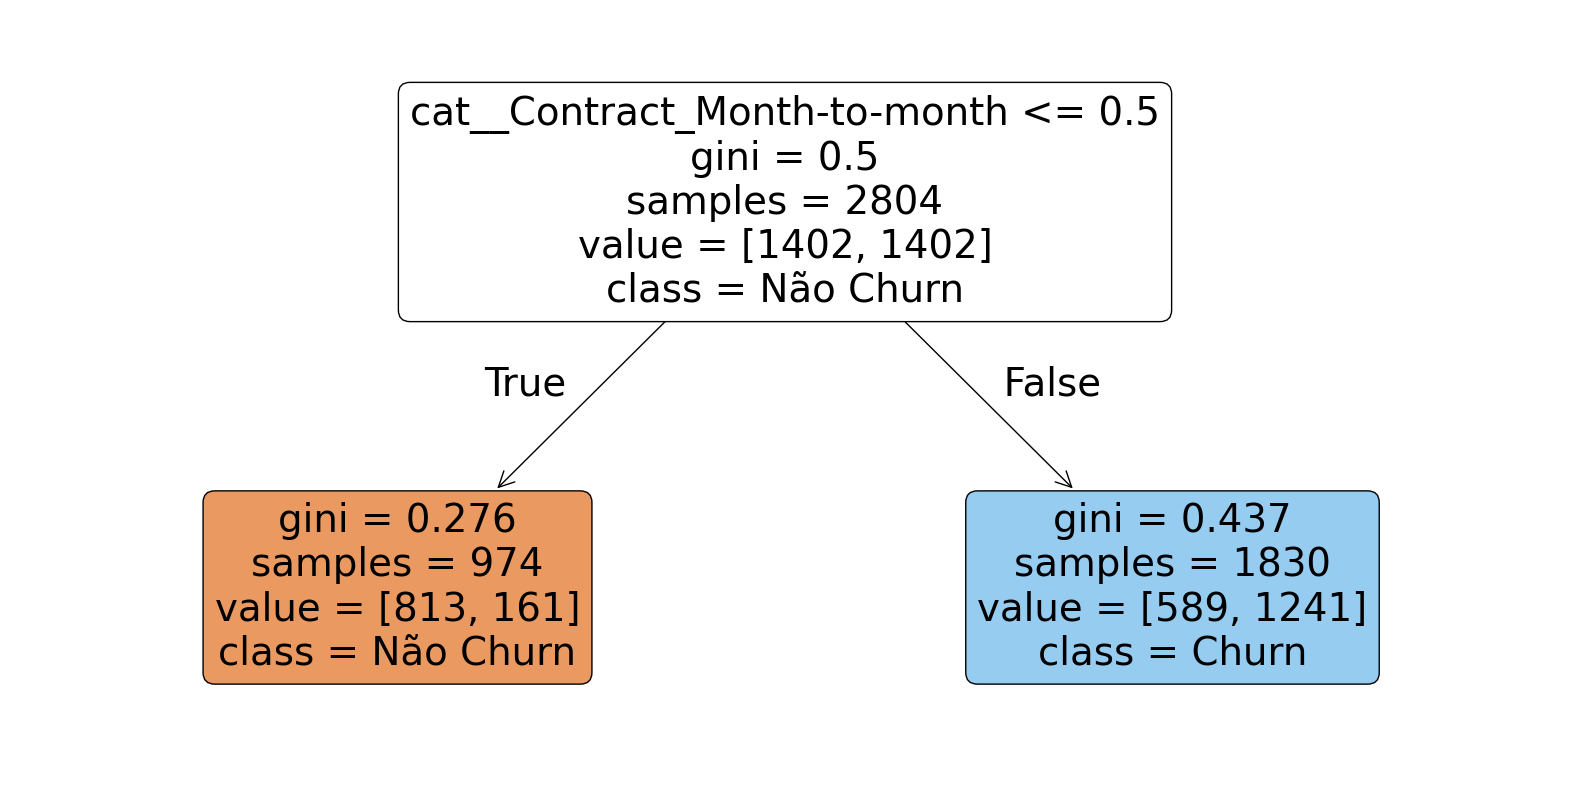

In [18]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

dtc_model = DecisionTreeClassifier(
    max_depth=1,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=RANDOM_STATE
)
    
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", dtc_model)
 ])

# Treina o pipeline
pipeline.fit(X_train_under, y_train_under)

# Recupera a árvore que foi efetivamente treinada
dtc_model = pipeline.named_steps["model"]

plot_tree(
    dtc_model,
    feature_names=pipeline.named_steps["preprocessor"].get_feature_names_out(),
    class_names=["Não Churn", "Churn"],
    filled=True,
    rounded=True
)

plt.show()

In [19]:
final_dtc = DecisionTreeClassifier(
    max_depth=1,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=RANDOM_STATE
)

# Pipeline
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", final_dtc)
])

# Treinamento com dados balanceados
final_pipeline.fit(X_train_under, y_train_under)

# Avaliação no conjunto de teste original
y_pred = final_pipeline.predict(X_test)
y_proba = final_pipeline.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.649032992036405
Precision: 0.4233128834355828
Recall: 0.8865096359743041
F1-Score: 0.5730103806228374
ROC-AUC: 0.7248194965309167


## Random Forest

In [20]:
def best_rf_params(X_train, y_train):
    
    # Valores dos hiperparâmetros que serão avaliados
    n_estimators_values = [50, 100, 150, 200]
    max_depth_values = [2, 3, 4, 5, 6, 7, 8]
    min_samples_split_values = [2, 5, 8, 10, 15, 20]
    min_samples_leaf_values = [1, 2, 5, 10, 15]
    
    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    }
    
    results = []
    
    for n_estimators in n_estimators_values:
        
        for max_depth in max_depth_values:
            
            for min_samples_split in min_samples_split_values:
                
                for min_samples_leaf in min_samples_leaf_values:
                    
                    # Criação do Random Forest
                    rf_model = RandomForestClassifier(
                        n_estimators=n_estimators,
                        max_depth=max_depth,
                        min_samples_split=min_samples_split,
                        min_samples_leaf=min_samples_leaf,
                        random_state=RANDOM_STATE,
                    )
                    
                    pipeline = Pipeline([
                        ("preprocessor", preprocessor),
                        ("model", rf_model)
                    ])
                    
                    # Validação cruzada utilizando somente X_train e y_train
                    scores = cross_validate(
                        pipeline,
                        X_train,
                        y_train,
                        cv=5,
                        scoring=scoring,
                        n_jobs=-1
                    )
                    
                    # Armazena os resultados
                    results.append({
                        "n_estimators": n_estimators,
                        "max_depth": max_depth,
                        "min_samples_split": min_samples_split,
                        "min_samples_leaf": min_samples_leaf,
                        "Accuracy": scores["test_accuracy"].mean(),
                        "Precision": scores["test_precision"].mean(),
                        "Recall": scores["test_recall"].mean(),
                        "F1 Score": scores["test_f1"].mean(),
                        "ROC-AUC_Mean": scores["test_roc_auc"].mean(),
                        "ROC-AUC_Std": scores["test_roc_auc"].std(),
                    })
    
    rf_results_df = pd.DataFrame(results)
    
    # Ordena do melhor para o pior resultado pelo Recall
    rf_results_df = rf_results_df.sort_values(
        by="Recall",
        ascending=False
    ).reset_index(drop=True)
    
    # Pega a primeira linha com os melhores parâmetros
    best_params = rf_results_df.iloc[0]
    
    print("Melhor combinação de hiperparâmetros:")
    print(f"n_estimators:       {best_params['n_estimators']}")
    print(f"max_depth:          {best_params['max_depth']}")
    print(f"min_samples_split:  {best_params['min_samples_split']}")
    print(f"min_samples_leaf:   {best_params['min_samples_leaf']}")
    
    return rf_results_df.head(10)

In [21]:
best_rf_params(X_train_under, y_train_under)

Melhor combinação de hiperparâmetros:
n_estimators:       200.0
max_depth:          2.0
min_samples_split:  2.0
min_samples_leaf:   2.0


,n_estimators,max_depth,min_samples_split,min_samples_leaf,Accuracy,Precision,Recall,F1 Score,ROC-AUC_Mean,ROC-AUC_Std
0,200,2,2,2,0.757486,0.724676,0.830981,0.774129,0.838465,0.010248
1,200,2,10,5,0.757486,0.724676,0.830981,0.774129,0.838465,0.010248
2,200,2,20,15,0.757486,0.724676,0.830981,0.774129,0.838465,0.010246
3,200,2,20,10,0.757486,0.724676,0.830981,0.774129,0.838463,0.010250
4,200,2,20,5,0.757486,0.724676,0.830981,0.774129,0.838465,0.010248
5,200,2,20,2,0.757486,0.724676,0.830981,0.774129,0.838465,0.010248
6,200,2,20,1,0.757486,0.724676,0.830981,0.774129,0.838465,0.010248
7,200,2,15,15,0.757486,0.724676,0.830981,0.774129,0.838465,0.010246
8,200,2,15,10,0.757486,0.724676,0.830981,0.774129,0.838463,0.010250
9,200,2,15,5,0.757486,0.724676,0.830981,0.774129,0.838465,0.010248


In [22]:
final_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=RANDOM_STATE
)

# Pipeline
final_pipeline_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", final_rf)
])

# Treinamento com dados balanceados
final_pipeline_rf.fit(X_train_under, y_train_under)

# Avaliação no conjunto de teste original
y_pred_rf = final_pipeline_rf.predict(X_test)
y_proba_rf = final_pipeline_rf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

Accuracy: 0.7258248009101251
Precision: 0.49019607843137253
Recall: 0.8029978586723768
F1-Score: 0.6087662337662337
ROC-AUC: 0.8374067212144032


## XGBoost

In [23]:
def best_xgb_params(X_train, y_train):
    
    # Valores dos hiperparâmetros que serão avaliados
    n_estimators_values = [50, 100, 150, 200]
    max_depth_values = [2, 3, 4, 5, 6, 7, 8]
    learning_rate_values = [0.01, 0.05, 0.1, 0.2]
    min_child_weight_values = [1, 3, 5]
    
    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    }
    
    results = []
    
    for n_estimators in n_estimators_values:
        
        for max_depth in max_depth_values:
            
            for learning_rate in learning_rate_values:
                
                for min_child_weight in min_child_weight_values:
                    
                    # Criação do XGBoost
                    xgb_model = XGBClassifier(
                        n_estimators=n_estimators,
                        max_depth=max_depth,
                        learning_rate=learning_rate,
                        min_child_weight=min_child_weight,
                        random_state=RANDOM_STATE,
                        eval_metric="logloss"
                    )
                    
                    pipeline = Pipeline([
                        ("preprocessor", preprocessor),
                        ("model", xgb_model)
                    ])
                    
                    # Validação cruzada utilizando somente X_train e y_train
                    scores = cross_validate(
                        pipeline,
                        X_train,
                        y_train,
                        cv=5,
                        scoring=scoring,
                        n_jobs=-1
                    )
                    
                    # Armazena os resultados
                    results.append({
                        "n_estimators": n_estimators,
                        "max_depth": max_depth,
                        "learning_rate": learning_rate,
                        "min_child_weight": min_child_weight,
                        "Accuracy": scores["test_accuracy"].mean(),
                        "Precision": scores["test_precision"].mean(),
                        "Recall": scores["test_recall"].mean(),
                        "F1 Score": scores["test_f1"].mean(),
                        "ROC-AUC_Mean": scores["test_roc_auc"].mean(),
                        "ROC-AUC_Std": scores["test_roc_auc"].std(),
                    })
    
    xgb_results_df = pd.DataFrame(results)
    
    # Ordena pelo Recall
    xgb_results_df = xgb_results_df.sort_values(
        by="Recall",
        ascending=False
    ).reset_index(drop=True)
    
    # Pega a primeira linha com os melhores parâmetros
    best_params = xgb_results_df.iloc[0]
    
    print("Melhor combinação de hiperparâmetros:")
    print(f"n_estimators:       {best_params['n_estimators']}")
    print(f"max_depth:          {best_params['max_depth']}")
    print(f"learning_rate:      {best_params['learning_rate']}")
    print(f"min_child_weight:   {best_params['min_child_weight']}")
    
    return xgb_results_df.head(10)

In [24]:
best_xgb_params(X_train_under, y_train_under)

Melhor combinação de hiperparâmetros:
n_estimators:       50.0
max_depth:          2.0
learning_rate:      0.01
min_child_weight:   1.0


,n_estimators,max_depth,learning_rate,min_child_weight,Accuracy,Precision,Recall,F1 Score,ROC-AUC_Mean,ROC-AUC_Std
0,50,2,0.01,1,0.736798,0.695632,0.848864,0.763172,0.824584,0.015682
1,50,2,0.01,5,0.736798,0.695632,0.848864,0.763172,0.824584,0.015682
2,50,2,0.01,3,0.736798,0.695632,0.848864,0.763172,0.824584,0.015682
3,100,2,0.01,1,0.744291,0.703861,0.846716,0.767839,0.836691,0.012931
4,100,2,0.01,5,0.744291,0.703861,0.846716,0.767839,0.836691,0.012931
5,100,2,0.01,3,0.744291,0.703861,0.846716,0.767839,0.836691,0.012931
6,150,2,0.01,5,0.757843,0.725785,0.830275,0.774164,0.841573,0.011148
7,150,2,0.01,3,0.757843,0.725785,0.830275,0.774164,0.841573,0.011148
8,150,2,0.01,1,0.757843,0.725785,0.830275,0.774164,0.841573,0.011148
9,100,3,0.01,5,0.757487,0.726754,0.825989,0.773004,0.841902,0.009448


In [25]:
# Modelo final
final_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    min_child_weight=1,
    random_state=RANDOM_STATE,
    eval_metric="logloss"
)

# Pipeline
final_pipeline_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", final_xgb)
])

# Treinamento com dados balanceados
final_pipeline_xgb.fit(X_train_under, y_train_under)

# Avaliação no conjunto de teste original
y_pred_xgb = final_pipeline_xgb.predict(X_test)
y_proba_xgb = final_pipeline_xgb.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1-Score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

Accuracy: 0.729806598407281
Precision: 0.4946949602122016
Recall: 0.7987152034261242
F1-Score: 0.6109746109746109
ROC-AUC: 0.836924881032747


# Conlusão

## Interpretação do modelo final

O modelo selecionado foi a **Árvore de Decisão**, utilizando `max_depth=1`, `min_samples_split=2` e `min_samples_leaf=1`. A escolha foi baseada principalmente no **Recall de 88,65%**, métrica priorizada neste projeto por representar a capacidade do modelo de identificar corretamente os clientes que realizaram churn. O modelo apresentou também **Precision de 64,90%** e **F1-Score de 57,30%**, indicando um equilíbrio adequado entre a identificação dos casos de churn e a quantidade de falsos positivos. O **ROC-AUC de 72,48%**, com desvio padrão de 1,95 ponto percentual na validação cruzada, indica capacidade discriminativa moderada e relativa estabilidade entre os folds. A **Accuracy de 64,90%** complementa a avaliação.

### Ações de negócio

Com base nas evidências encontradas, podem ser propostas três ações:

1. **Priorizar clientes com maior propensão ao churn**, direcionando ações de retenção para os grupos classificados pelo modelo como de maior risco.
2. **Criar estratégias específicas para clientes nos primeiros meses de relacionamento**, considerando a maior concentração de churn observada nesse período.
3. **Desenvolver campanhas de retenção segmentadas**, utilizando as características associadas ao maior risco de churn para direcionar ofertas, benefícios e ações de relacionamento.

### Limitações

A base utilizada é uma **amostra de exemplo disponibilizada pela IBM**, portanto os resultados não devem ser tratados como diagnóstico de clientes reais nem generalizados diretamente para outros contextos. O desempenho do modelo depende da amostra, das variáveis disponíveis, do pré-processamento e dos hiperparâmetros utilizados. Além disso, as associações identificadas pelo modelo **não estabelecem relações de causalidade**.